In [1]:
import os
import time
import numpy as np
import seaborn as sns
from numpy.polynomial.legendre import leggauss
from matplotlib import pyplot as plt

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
folder = "./nitscheFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"

directory ./nitscheFEM already created


In [4]:
# Funções analíticas

def exact_u(x):
    return np.cos(np.pi * x)

def exact_f(x):
    return (np.pi ** 2)*np.cos(np.pi*x)

In [5]:
def compute_L2_error(nodes, elements, u_app):
    gauss_pts, weights = leggauss(3)

    error_sq = 0.0

    for e in elements:
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]
        u_loc = np.array([u_app[n1], u_app[n2]])

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])

            x_gp = N[0] * x1 + N[1] * x2
            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

In [6]:
def compute_L2_error_discontinuous(nodes, elements, u_app):
    gauss_pts, weights = leggauss(3)

    error_sq = 0.0

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]
        u_loc = u_app[elem_id, :]

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])

            x_gp = N[0] * x1 + N[1] * x2

            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

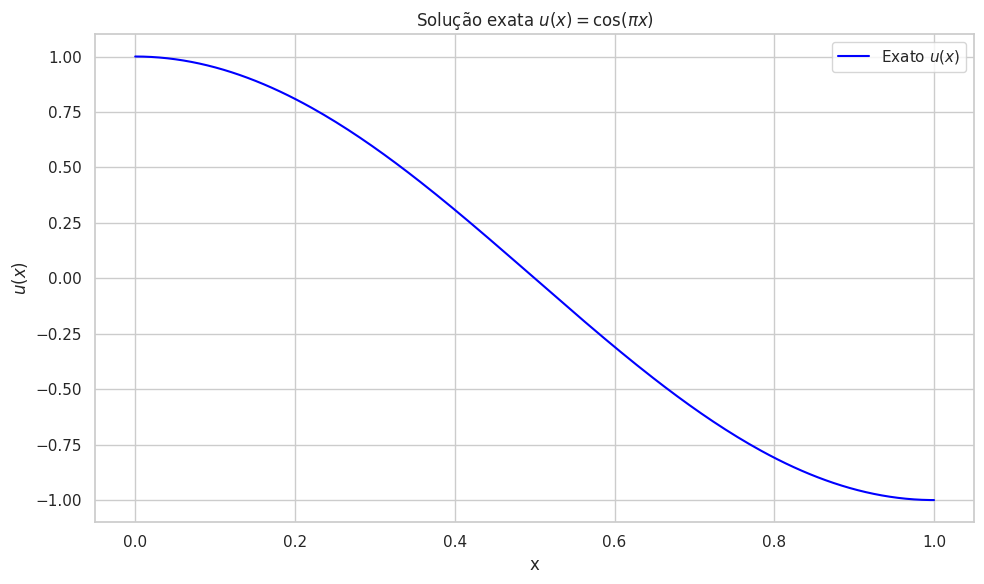

In [7]:
x_exact = np.linspace(0, 1, 200)

plt.figure(figsize=(10, 6))

plt.plot(x_exact, exact_u(x_exact), '-', label=r'Exato $u(x)$', color='blue')

plt.title(r'Solução exata $u(x) = \cos(\pi x)$')
plt.xlabel('x')
plt.ylabel(r'$u(x)$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "exato.pdf")
plt.show()

In [8]:
# Função de criação de malha

def create_mesh(l, n_elem):
    nodes = np.linspace(0, l, n_elem+1)
    elements = np.array([[i, i+1] for i in range(n_elem)])
    return nodes, elements

In [9]:
def local_matrices(x1, x2):
    h = x2 - x1
    J = h / 2.0  # Jacobiano da transformação

    # Pontos e pesos da Quadratura de Gauss
    gauss_pts = [-1/np.sqrt(3), 1/np.sqrt(3)]
    weights = [1.0, 1.0]

    K_loc = np.zeros((2, 2))
    F_loc = np.zeros(2)

    for gp, w in zip(gauss_pts, weights):
        # Aqui defino as funções de forma (N) e derivadas (dN/dx) para a aproximação linear
        N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])
        dN_dxi = np.array([-0.5, 0.5])
        dN_dx = dN_dxi / J

        # Coordenada x real no ponto de integração
        x_gp = N[0]*x1 + N[1]*x2
        f_val = exact_f(x_gp)

        for i in range(2):
            F_loc[i] += f_val * N[i] * w * J
            for j in range(2):
                K_uu = dN_dx[i] * dN_dx[j]
                K_loc[i, j] += K_uu * w * J

    return K_loc, F_loc

In [10]:
# Montagem Global e Resolução com Nitsche
def solve_nitsche(l, n_elem, alpha, beta):
    nodes, elements = create_mesh(l, n_elem)
    n_nodes = len(nodes)
    n_dof = n_nodes

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    # 1. Montagem Padrão (Volume)
    for e in elements:
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]
        K_loc, F_loc = local_matrices(x1, x2)

        dofs = [n1, n2]

        for i in range(2):
            F_global[dofs[i]] += F_loc[i]
            for j in range(2):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    # 2. Imposição Fraca das Condições de Dirichlet (Nitsche)
    h = l / n_elem
    g_0 = exact_u(0.0)
    g_1 = exact_u(l)

    # Contorno em x = 0 (Nó 0)
    K_global[0, 0] += -1.0/h + alpha/h + beta
    K_global[0, 1] += 1.0/h
    K_global[1, 0] += -alpha/h
    
    F_global[0] += (alpha/h + beta) * g_0
    F_global[1] += (-alpha/h) * g_0

    # Contorno em x = L (Nó final)
    N_idx = n_elem
    K_global[N_idx, N_idx] += -1.0/h + alpha/h + beta
    K_global[N_idx, N_idx-1] += 1.0/h
    K_global[N_idx-1, N_idx] += -alpha/h
    
    F_global[N_idx] += (alpha/h + beta) * g_1
    F_global[N_idx-1] += (-alpha/h) * g_1

    # Resolução do sistema linear
    # U_global = np.linalg.solve(K_global, F_global)
    # Tentei fazer aqui uma maneira de evitar que de erro se a matriz for singular... graças a Deus aprendi esse tratamento de exceção
    try:
        u_app = np.linalg.solve(K_global, F_global)
    except np.linalg.LinAlgError:
        print(f"Matriz singular para alpha={alpha}, beta={beta}. Usando mínimos quadrados.")
        u_app = np.linalg.lstsq(K_global, F_global, rcond=None)[0]

    return nodes, elements, u_app, K_global

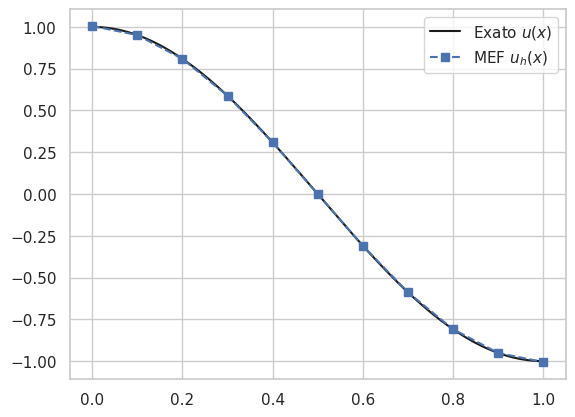

In [11]:
L = 1.0
n_elem = 10

alphas = [-1, 0, 1]
betas = [0, 1, 10, 100]

x_exact = np.linspace(0, L, 200)

nodes, elements, u_approx, K_global = solve_nitsche(L, n_elem=10, alpha=-1, beta=100)

plt.plot(x_exact, exact_u(x_exact), 'k-', label='Exato $u(x)$')
plt.plot(nodes, u_approx, 'bs--', label='MEF $u_h(x)$')
plt.legend()

In [12]:
def experiment_b():
    L = 1.0
    n_elem = 20

    alphas = [-1, 0, 1]
    betas = [0, 1, 10, 100]

    x_exact = np.linspace(0, L, 300)

    plt.figure(figsize=(18, 12))

    print("RESULTADOS LETRA (b) - MÉTODO DE NITSCHE")
    print("-" * 90)
    print(f"{'alpha':<8} | {'beta':<8} | {'Erro L2':<12} | {'cond(K)':<12} | {'u_h(0)':<12} | {'u_h(1)':<12}")
    print("-" * 90)

    count = 1

    for alpha in alphas:
        for beta in betas:
            nodes, elements, u_app, K_global = solve_nitsche(L, n_elem, alpha, beta)

            err_L2 = compute_L2_error(nodes, elements, u_app)
            cond_K = np.linalg.cond(K_global)

            print(
                f"{alpha:<8} | {beta:<8} | {err_L2:<12.3e} | "
                f"{cond_K:<12.3e} | {u_app[0]:<12.6f} | {u_app[-1]:<12.6f}"
            )

            plt.subplot(len(alphas), len(betas), count)

            plt.plot(x_exact, exact_u(x_exact), 'k--', label='Exata')
            plt.plot(nodes, u_app, 'bo-', label='Aproximada')

            plt.title(rf'$\alpha={alpha}$, $\beta={beta}$')
            plt.xlabel('x')
            plt.ylabel('u(x)')
            plt.grid(True)

            if count == 1:
                plt.legend()

            count += 1

    print("-" * 90)

    plt.tight_layout()
    plt.savefig(folder + "letra_b_nitsche.pdf")
    plt.show()

RESULTADOS LETRA (b) - MÉTODO DE NITSCHE
------------------------------------------------------------------------------------------
alpha    | beta     | Erro L2      | cond(K)      | u_h(0)       | u_h(1)      
------------------------------------------------------------------------------------------
-1       | 0        | 3.180e-03    | 1.614e+02    | 0.987688     | -0.987688   
-1       | 1        | 3.285e-03    | 1.614e+02    | 0.987040     | -0.987040   
-1       | 10       | 5.272e-03    | 1.614e+02    | 0.975377     | -0.975377   
-1       | 100      | 1.490e-03    | 1.624e+02    | 1.003078     | -1.003078   
Matriz singular para alpha=0, beta=0. Usando mínimos quadrados.
0        | 0        | 6.854e-01    | 2.452e+17    | -0.184725    | 0.184725    
0        | 1        | 1.407e-01    | 2.965e+02    | 1.246233     | -1.246233   
0        | 10       | 1.279e-02    | 1.631e+02    | 1.024623     | -1.024623   
0        | 100      | 6.754e-04    | 2.083e+02    | 1.002462     | -1.002

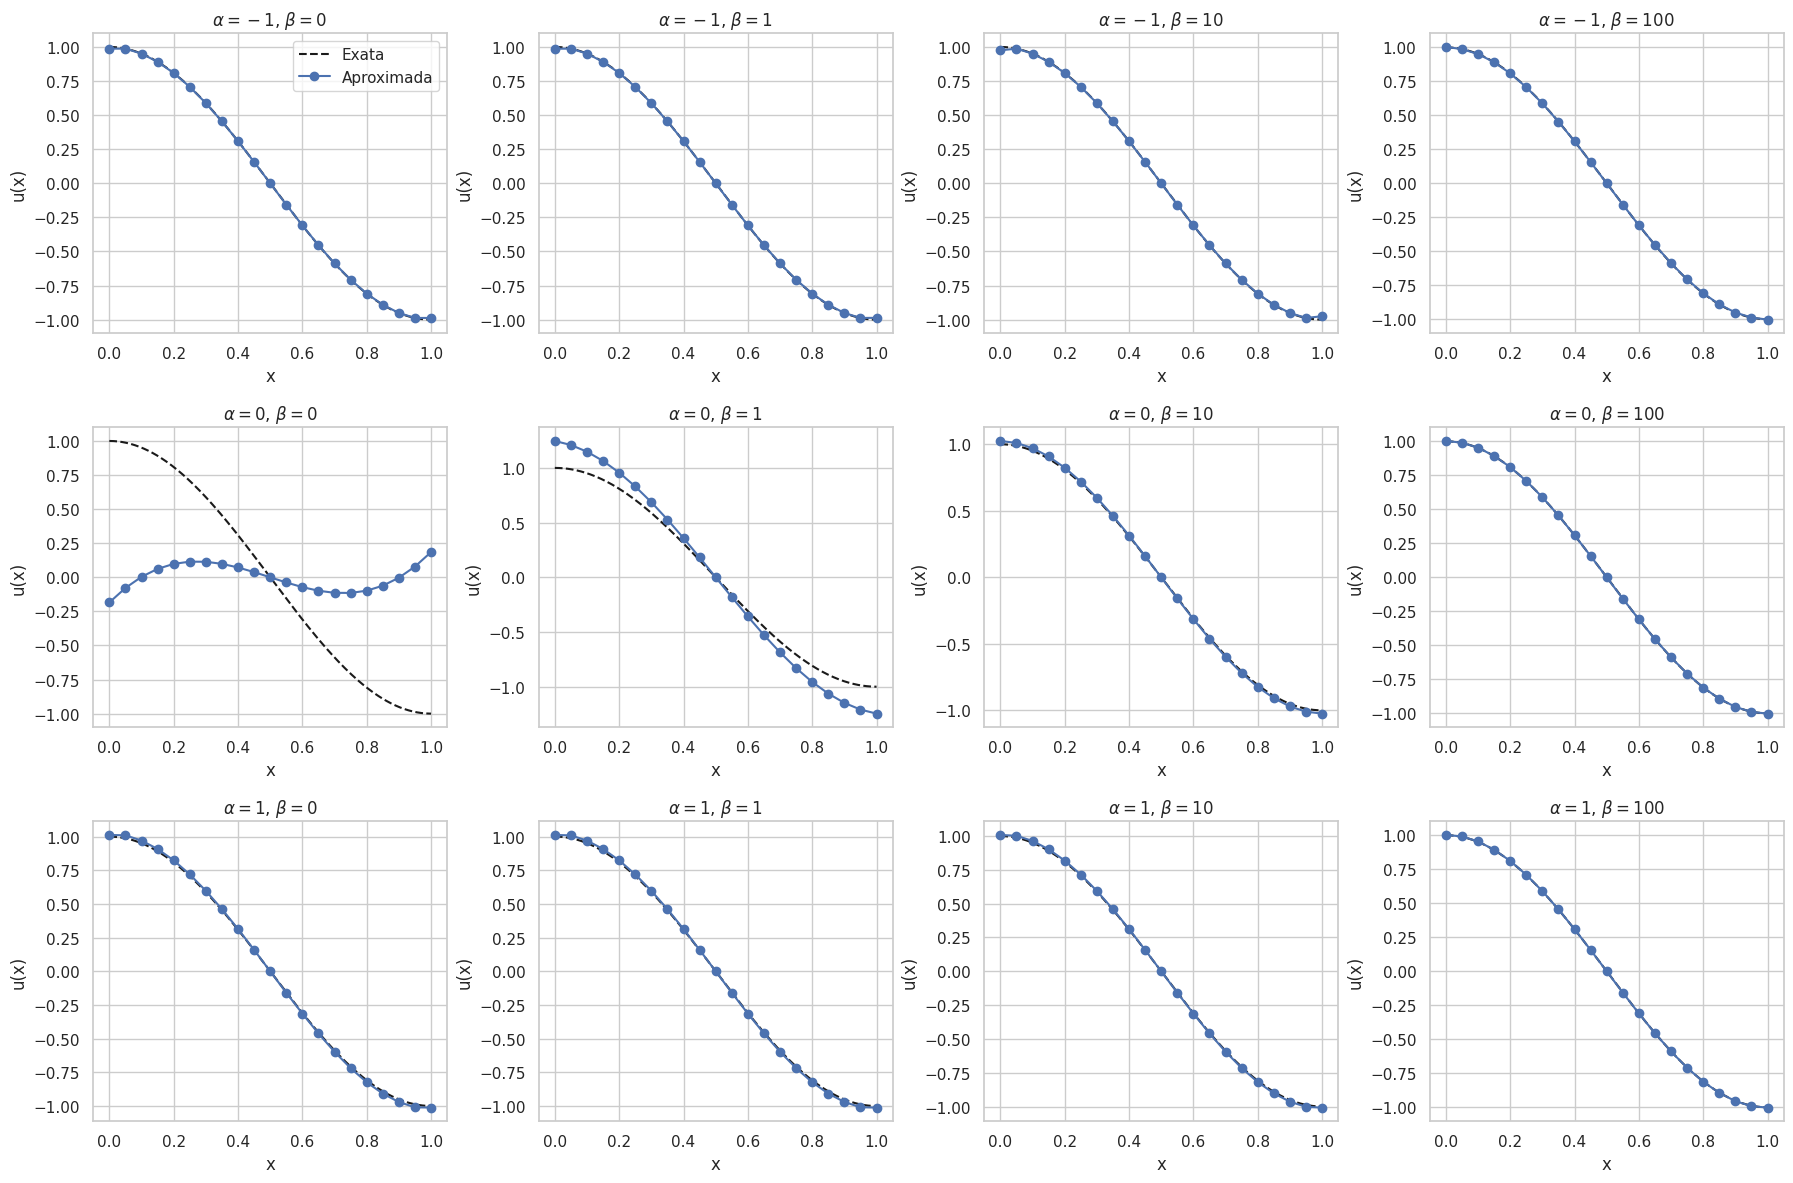

In [13]:
experiment_b()

In [14]:
folder = "./hybridKnownLambdaFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"

directory ./hybridKnownLambdaFEM already created


In [15]:
def local_matrices_discontinuous_known_lambda(x1, x2, alpha, beta):
    # pass
    h = x2 - x1
    J = h / 2.0
    
    # Pontos e pesos da quadratura de Gauss
    gauss_pts, weights = leggauss(2)
    
    K_loc = np.zeros((2, 2))
    F_loc = np.zeros(2)
    
    for gp, w in zip(gauss_pts, weights):
        # Aqui defino as funções de forma (N) e derivadas (dN/dx) para a aproximação linear
        N = np.array([0.5 * (1 - gp), 0.5 * (1 + gp)])
        dN_dxi = np.array([-0.5, 0.5])
        dN_dx = dN_dxi / J

        # Recupero as coodenadas originais
        x_gp = N[0] * x1 + N[1] * x2
        f_val = exact_f(x_gp)

        for i in range(2):
            for j in range(2):
                K_loc[i, j] += dN_dx[i] * dN_dx[j] * w * J

            F_loc[i] += f_val * N[i] * w * J
    
    # Termos de contorno locais
    
    # Convenção:
    # x1: normal n = -1
    # x2: normal n =  1
    #
    # lambda é conhecido:
    # lambda(x) = u_exata(x)
    
    dN_dx = np.array([-1.0 / h, 1.0 / h])

    boundary_points = [
        # ponto esquerdo do elemento
        {
            "x": x1,
            "normal": -1.0,
            "N": np.array([1.0, 0.0])
        },
        # ponto direito do elemento
        {
            "x": x2,
            "normal": 1.0,
            "N": np.array([0.0, 1.0])
        }
    ]
    
    for bd in boundary_points:
        xb = bd["x"]
        normal = bd["normal"]
        N_boundary = bd["N"]

        lambda_val = exact_u(xb)

        for i in range(2):      # índice da função teste
            # Lado direito:
            # alpha * v' * n * lambda + beta * lambda * v
            F_loc[i] += alpha * dN_dx[i] * normal * lambda_val
            F_loc[i] += beta * lambda_val * N_boundary[i]

            for j in range(2):  # índice da função tentativa
                # Matriz local:
                # - u' * n * v
                K_loc[i, j] += -dN_dx[j] * normal * N_boundary[i]

                # + alpha * v' * n * u
                K_loc[i, j] += alpha * dN_dx[i] * normal * N_boundary[j]

                # + beta * u * v
                K_loc[i, j] += beta * N_boundary[j] * N_boundary[i]

    return K_loc, F_loc    

In [16]:
def solve_discontinuous_known_lambda(l, n_elem, alpha, beta):
    # pass
    nodes, elements = create_mesh(l, n_elem)

    # Como a solução é descontínua, cada elemento tem seus próprios
    # dois graus de liberdade locais.
    u_app = np.zeros((n_elem, 2))
    
    cond_numbers = []

    for elem_id, e in enumerate(elements):
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]

        K_loc, F_loc = local_matrices_discontinuous_known_lambda(
            x1,
            x2,
            alpha,
            beta
        )

        cond_numbers.append(np.linalg.cond(K_loc))

        try:
            u_loc = np.linalg.solve(K_loc, F_loc)
        except np.linalg.LinAlgError:
            print(
                f"Matriz local singular no elemento {elem_id}, "
                f"alpha={alpha}, beta={beta}. Usando mínimos quadrados."
            )
            u_loc = np.linalg.lstsq(K_loc, F_loc, rcond=None)[0]

        u_app[elem_id, :] = u_loc

    return nodes, elements, u_app, cond_numbers


In [17]:
def build_discontinuous_plot_data(nodes, elements, u_app):
    # pass
    x_plot = []
    u_plot = []

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x_plot.append(nodes[n1])
        x_plot.append(nodes[n2])
        x_plot.append(np.nan)

        u_plot.append(u_app[elem_id, 0])
        u_plot.append(u_app[elem_id, 1])
        u_plot.append(np.nan)

    return np.array(x_plot), np.array(u_plot)

In [18]:
def compute_max_jump(elements, u_app):
    # pass
    jumps = []

    for elem_id in range(len(elements) - 1):
        u_left = u_app[elem_id, 1]
        u_right = u_app[elem_id + 1, 0]

        jumps.append(abs(u_left - u_right))

    if len(jumps) == 0:
        return 0.0

    return max(jumps)


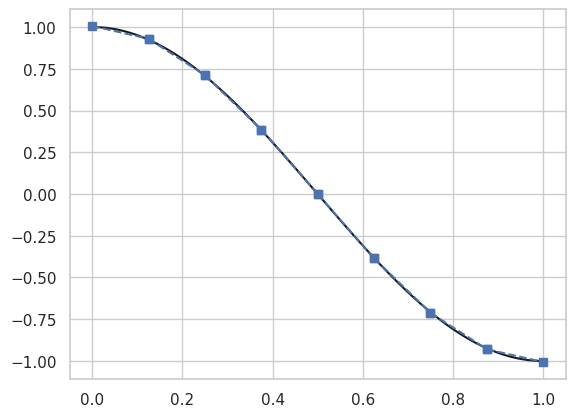

In [19]:
L = 1.0
n_elem = 10

alphas = [-1, 0, 1]
betas = [0, 1, 10, 100]

x_exact = np.linspace(0, L, 300)

nodes, elements, u_app, cond_numbers = solve_discontinuous_known_lambda(L, n_elem=8, alpha=-1, beta=100)

x_disc, u_disc = build_discontinuous_plot_data(nodes, elements, u_app)

plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
plt.plot(x_disc, u_disc, 'bs--', label=r'Descontínua $u_h(x)$')

# plt.legend()

In [20]:
def experiment_d():
    # pass
    L = 1.0
    n_elem = 10

    alphas = [-1, 0, 1]
    betas = [0, 1, 10, 100]

    x_exact = np.linspace(0, L, 300)

    plt.figure(figsize=(18, 12))

    print("RESULTADOS LETRA (d) - FORMULAÇÃO DESCONTÍNUA COM LAMBDA CONHECIDO")
    print("-" * 105)
    print(
        f"{'alpha':<8} | {'beta':<8} | {'Erro L2':<12} | "
        f"{'Max salto':<12} | {'cond max':<12} | {'u_h(0)':<12} | {'u_h(1)':<12}"
    )
    print("-" * 105)

    count = 1

    for alpha in alphas:
        for beta in betas:
            nodes, elements, u_app, cond_numbers = solve_discontinuous_known_lambda(
                L,
                n_elem,
                alpha,
                beta
            )

            x_disc, u_disc = build_discontinuous_plot_data(nodes, elements, u_app)

            err_L2 = compute_L2_error_discontinuous(nodes, elements, u_app)
            max_jump = compute_max_jump(elements, u_app)
            cond_max = max(cond_numbers)

            print(
                f"{alpha:<8} | {beta:<8} | {err_L2:<12.3e} | "
                f"{max_jump:<12.3e} | {cond_max:<12.3e} | "
                f"{u_app[0, 0]:<12.6f} | {u_app[-1, 1]:<12.6f}"
            )

            plt.subplot(len(alphas), len(betas), count)

            plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
            plt.plot(x_disc, u_disc, 'bs--', label=r'Descontínua $u_h(x)$')

            plt.title(rf'$\alpha={alpha}$, $\beta={beta}$')
            plt.xlabel('x')
            plt.ylabel('u(x)')
            plt.grid(True)

            if count == 1:
                plt.legend()

            count += 1

    print("-" * 105)

    plt.tight_layout()
    plt.savefig(folder + "letra_d_descontinua_lambda_conhecido.pdf")
    plt.show()

RESULTADOS LETRA (d) - FORMULAÇÃO DESCONTÍNUA COM LAMBDA CONHECIDO
---------------------------------------------------------------------------------------------------------
alpha    | beta     | Erro L2      | Max salto    | cond max     | u_h(0)       | u_h(1)      
---------------------------------------------------------------------------------------------------------
Matriz local singular no elemento 0, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 1, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 2, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 3, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 4, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 5, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 6, alpha=-1, beta=0. Usando mínimos quadrados.
Matriz local singular no elemento 7, alpha=-1, beta=0. Usan

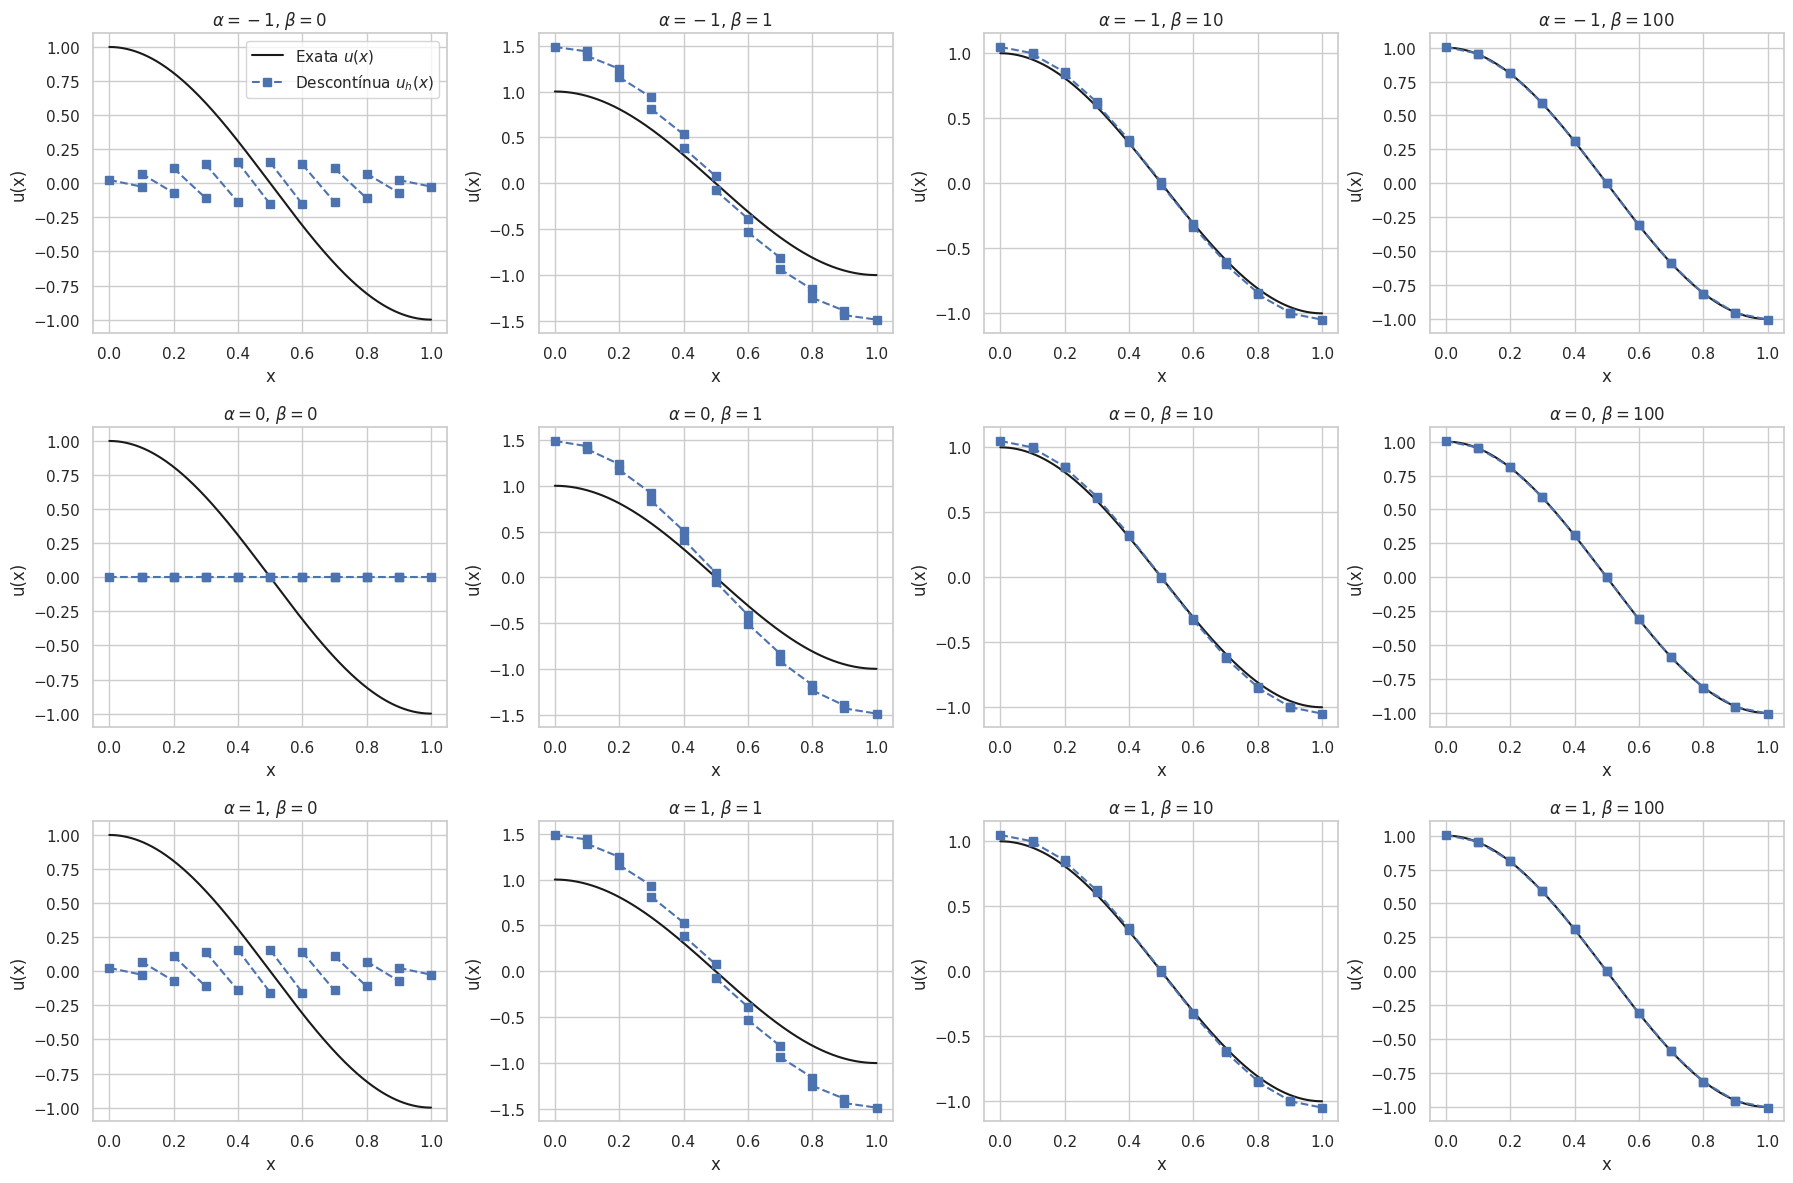

In [21]:
experiment_d()

In [22]:
folder = "./hybridCompleteFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"

directory ./hybridCompleteFEM already created


In [23]:
# Redefinindo as funções exatas
def exact_u(x):
    return np.sin(np.pi * x)

def exact_f(x):
    return (np.pi**2) * np.sin(np.pi * x)


In [24]:
def create_mesh_high_order(l, n_elem, k):
    n_nodes = n_elem * k + 1
    nodes = np.linspace(0, l, n_nodes)

    elements = []
    for e in range(n_elem):
        start_ix = e * k
        elem_nodes = [start_ix + i for i in range(k + 1)]
        elements.append(elem_nodes)

    return nodes, np.array(elements)

In [25]:
def lagrange_shape(k, xi):
    # Aqui faço N e dN/dxi para elemento de grau k no intervalo [-1, 1]
    xi_nodes = np.linspace(-1, 1, k + 1)

    N = np.zeros(k + 1)
    dN_dxi = np.zeros(k + 1)

    for i in range(k + 1):
        p_val = 1.0

        for j in range(k + 1):
            if i != j:
                p_val *= (xi - xi_nodes[j]) / (xi_nodes[i] - xi_nodes[j])

        N[i] = p_val

        dp_val = 0.0

        for j in range(k + 1):
            if i != j:
                term = 1.0 / (xi_nodes[i] - xi_nodes[j])

                for m in range(k + 1):
                    if m != i and m != j:
                        term *= (xi - xi_nodes[m]) / (xi_nodes[i] - xi_nodes[m])

                dp_val += term

        dN_dxi[i] = dp_val

    return N, dN_dxi

In [26]:
def local_matrices_hybrid(x1, x2, k, alpha, beta):
    h = x2 - x1
    J = h / 2.0

    n_loc_nodes = k + 1

    A_loc = np.zeros((n_loc_nodes, n_loc_nodes))
    B_loc = np.zeros((n_loc_nodes, 2))
    D_loc = np.zeros((2, n_loc_nodes))
    C_loc = np.zeros((2, 2))
    F_loc = np.zeros(n_loc_nodes)

    # Integração dos termos de volume
    gauss_pts, weights = leggauss(k + 2)

    x_coords = np.linspace(x1, x2, k + 1)

    for gp, w in zip(gauss_pts, weights):
        N, dN_dxi = lagrange_shape(k, gp)
        dN_dx = dN_dxi / J

        x_gp = np.dot(N, x_coords)
        f_val = exact_f(x_gp)

        for i in range(n_loc_nodes):
            F_loc[i] += f_val * N[i] * w * J

            for j in range(n_loc_nodes):
                A_loc[i, j] += dN_dx[i] * dN_dx[j] * w * J

    # Termos de fronteira locais
    # Em 1D:
    # ponto esquerdo: normal = -1
    # ponto direito: normal =  1

    boundary_data = [
        {"xi": -1.0, "normal": -1.0, "lambda_index": 0},
        {"xi":  1.0, "normal":  1.0, "lambda_index": 1}
    ]

    for bd in boundary_data:
        xi_b = bd["xi"]
        normal = bd["normal"]
        lambda_index = bd["lambda_index"]

        N_b, dN_dxi_b = lagrange_shape(k, xi_b)
        dN_dx_b = dN_dxi_b / J

        for i in range(n_loc_nodes):      # função teste v
            for j in range(n_loc_nodes):  # função tentativa u

                # A:
                # int u' v'
                # - int_boundary u' n v
                # + alpha int_boundary v' n u
                # + beta int_boundary u v

                A_loc[i, j] += -dN_dx_b[j] * normal * N_b[i]
                A_loc[i, j] += alpha * dN_dx_b[i] * normal * N_b[j]
                A_loc[i, j] += beta * N_b[j] * N_b[i]

            # B:
            # - alpha int_boundary v' n lambda
            # - beta int_boundary lambda v

            B_loc[i, lambda_index] += -alpha * dN_dx_b[i] * normal
            B_loc[i, lambda_index] += -beta * N_b[i]

        for j in range(n_loc_nodes):      # função tentativa u
            # D:
            # int_boundary u' n mu
            # - beta int_boundary u mu

            D_loc[lambda_index, j] += dN_dx_b[j] * normal
            D_loc[lambda_index, j] += -beta * N_b[j]

        # C:
        # beta int_boundary lambda mu

        C_loc[lambda_index, lambda_index] += beta

    return A_loc, B_loc, D_loc, C_loc, F_loc

In [27]:
def solve_hybrid_static_condensation(l, n_elem, k, alpha, beta0):
    nodes, elements = create_mesh(l, n_elem)

    n_lambda = len(nodes)

    K_lambda = np.zeros((n_lambda, n_lambda))
    F_lambda = np.zeros(n_lambda)

    local_data = []

    h = l / n_elem
    beta = (k**2) * beta0 / h

    for elem_id, e in enumerate(elements):
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]

        A_loc, B_loc, D_loc, C_loc, F_loc = local_matrices_hybrid(
            x1,
            x2,
            k,
            alpha,
            beta
        )

        # Condensação estática:
        # U = A^{-1}(F - B Lambda)
        #
        # Sistema global:
        # (D A^{-1} B - C) Lambda = D A^{-1} F

        A_inv_B = np.linalg.solve(A_loc, B_loc)
        A_inv_F = np.linalg.solve(A_loc, F_loc)

        K_loc_lambda = D_loc @ A_inv_B - C_loc
        F_loc_lambda = D_loc @ A_inv_F

        lambda_dofs = [n1, n2]

        for i in range(2):
            F_lambda[lambda_dofs[i]] += F_loc_lambda[i]

            for j in range(2):
                K_lambda[lambda_dofs[i], lambda_dofs[j]] += K_loc_lambda[i, j]

        local_data.append({
            "A": A_loc,
            "B": B_loc,
            "F": F_loc,
            "lambda_dofs": lambda_dofs
        })

    # Condições de contorno para lambda
    # Como u = sin(pi x), temos u(0)=0 e u(1)=0.
    fixed_dofs = [0, n_lambda - 1]
    fixed_values = [exact_u(0.0), exact_u(l)]

    for dof, value in zip(fixed_dofs, fixed_values):
        F_lambda -= K_lambda[:, dof] * value

        K_lambda[dof, :] = 0.0
        K_lambda[:, dof] = 0.0
        K_lambda[dof, dof] = 1.0

        F_lambda[dof] = value

    lambda_app = np.linalg.solve(K_lambda, F_lambda)

    # Recuperação local de u_h em cada elemento:
    # U = A^{-1}(F - B Lambda)

    u_app = np.zeros((n_elem, k + 1))

    for elem_id, data in enumerate(local_data):
        A_loc = data["A"]
        B_loc = data["B"]
        F_loc = data["F"]
        lambda_dofs = data["lambda_dofs"]

        lambda_loc = lambda_app[lambda_dofs]

        u_loc = np.linalg.solve(A_loc, F_loc - B_loc @ lambda_loc)

        u_app[elem_id, :] = u_loc

    return nodes, elements, lambda_app, u_app, K_lambda, beta


In [28]:
def solve_galerkin_classic(l, n_elem, k):
    nodes, elements = create_mesh_high_order(l, n_elem, k)

    n_nodes = len(nodes)

    K_global = np.zeros((n_nodes, n_nodes))
    F_global = np.zeros(n_nodes)

    gauss_pts, weights = leggauss(k + 2)

    for elem_nodes in elements:
        x_coords = nodes[elem_nodes]

        h = x_coords[-1] - x_coords[0]
        J = h / 2.0

        n_loc_nodes = k + 1

        K_loc = np.zeros((n_loc_nodes, n_loc_nodes))
        F_loc = np.zeros(n_loc_nodes)

        for gp, w in zip(gauss_pts, weights):
            N, dN_dxi = lagrange_shape(k, gp)
            dN_dx = dN_dxi / J

            x_gp = np.dot(N, x_coords)
            f_val = exact_f(x_gp)

            for i in range(n_loc_nodes):
                F_loc[i] += f_val * N[i] * w * J

                for j in range(n_loc_nodes):
                    K_loc[i, j] += dN_dx[i] * dN_dx[j] * w * J

        for i in range(n_loc_nodes):
            F_global[elem_nodes[i]] += F_loc[i]

            for j in range(n_loc_nodes):
                K_global[elem_nodes[i], elem_nodes[j]] += K_loc[i, j]

    # Condição de contorno de Dirichlet forte
    fixed_dofs = [0, n_nodes - 1]
    fixed_values = [exact_u(0.0), exact_u(l)]

    for dof, value in zip(fixed_dofs, fixed_values):
        F_global -= K_global[:, dof] * value

        K_global[dof, :] = 0.0
        K_global[:, dof] = 0.0
        K_global[dof, dof] = 1.0

        F_global[dof] = value

    u_app = np.linalg.solve(K_global, F_global)

    return nodes, elements, u_app, K_global

In [29]:
def compute_L2_error_hybrid(nodes, elements, u_app, k):
    gauss_pts, weights = leggauss(k + 4)

    error_sq = 0.0

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]
        x_coords = np.linspace(x1, x2, k + 1)

        u_loc = u_app[elem_id, :]

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N, _ = lagrange_shape(k, gp)

            x_gp = np.dot(N, x_coords)

            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

In [30]:
def compute_L2_error_galerkin(nodes, elements, u_app, k):
    gauss_pts, weights = leggauss(k + 4)

    error_sq = 0.0

    for elem_nodes in elements:
        x_coords = nodes[elem_nodes]
        u_loc = u_app[elem_nodes]

        h = x_coords[-1] - x_coords[0]
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N, _ = lagrange_shape(k, gp)

            x_gp = np.dot(N, x_coords)

            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

In [31]:
def build_hybrid_plot_data(nodes, elements, u_app, k):
    x_plot = []
    u_plot = []

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]

        x_elem = np.linspace(x1, x2, k + 1)
        u_elem = u_app[elem_id, :]

        for i in range(k + 1):
            x_plot.append(x_elem[i])
            u_plot.append(u_elem[i])

        x_plot.append(np.nan)
        u_plot.append(np.nan)

    return np.array(x_plot), np.array(u_plot)

In [32]:
L = 1.0
beta0 = 10.0

k_values = [1, 2, 3, 4]
alpha_values = [-1, 0, 1]
mesh_sizes = [4, 8, 16, 32, 64]

nodes_gal, elements_gal, u_gal, K_gal = solve_galerkin_classic(L, 16, 1)

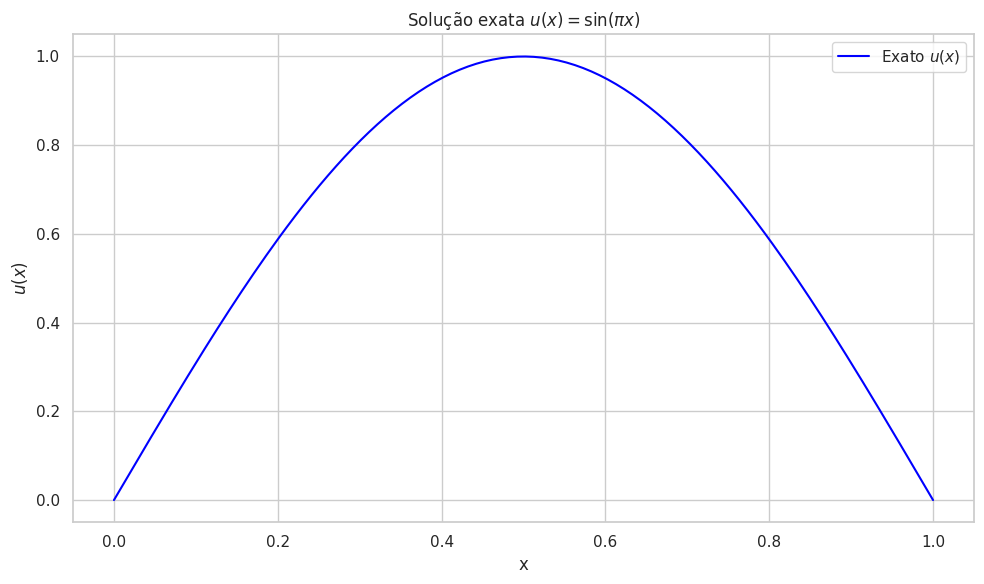

In [33]:
x_exact = np.linspace(0, 1, 200)

plt.figure(figsize=(10, 6))

plt.plot(x_exact, exact_u(x_exact), '-', label=r'Exato $u(x)$', color='blue')

plt.title(r'Solução exata $u(x) = \sin(\pi x)$')
plt.xlabel('x')
plt.ylabel(r'$u(x)$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "exato_02.pdf")
plt.show()

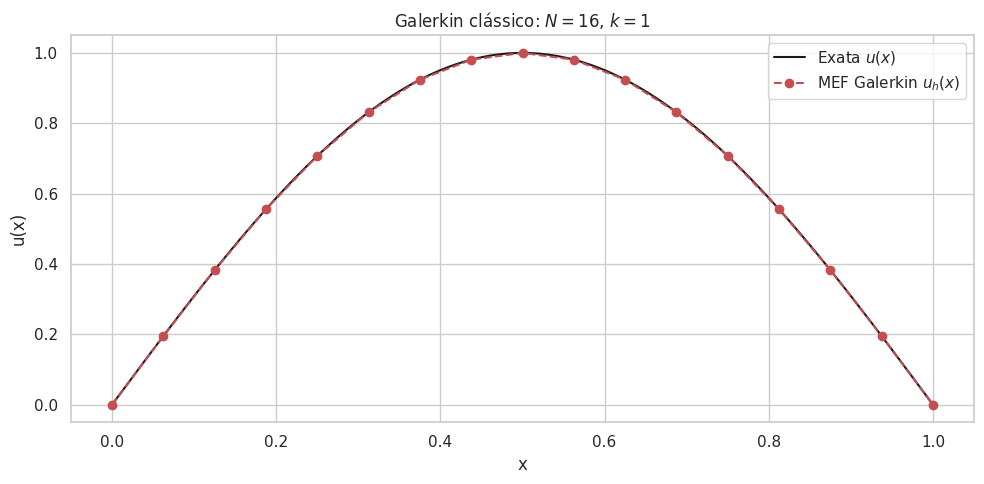

In [34]:
L = 1.0
n_elem = 16
k = 1

nodes_gal, elements_gal, u_gal, K_gal = solve_galerkin_classic(L, n_elem, k)

x_exact = np.linspace(0, L, 300)

plt.figure(figsize=(10, 5))

plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
plt.plot(nodes_gal, u_gal, 'ro--', label=r'MEF Galerkin $u_h(x)$')

plt.title(rf'Galerkin clássico: $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + f"galerkin_classico_N{n_elem}_k{k}.pdf")
plt.show()

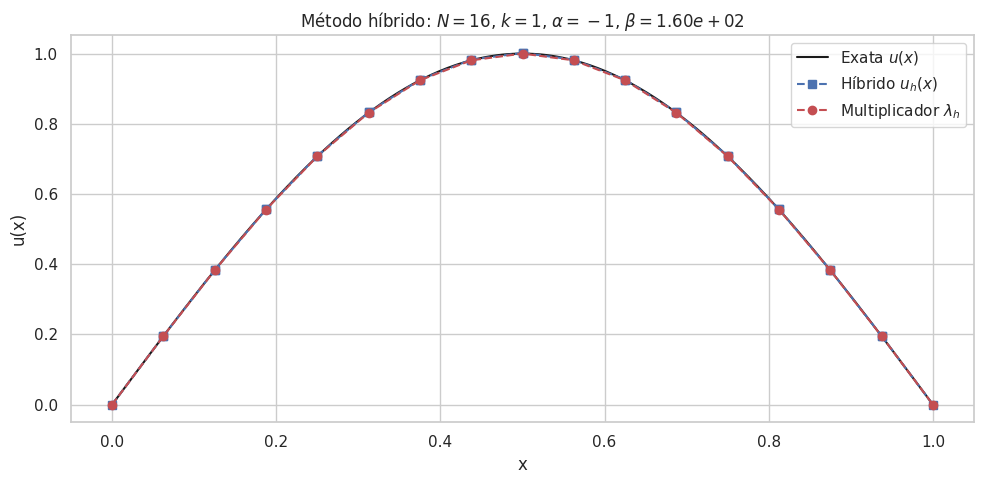

In [35]:
nodes_hyb, elements_hyb, lambda_app, u_hyb, K_lambda, beta = solve_hybrid_static_condensation(
    L,
    n_elem,
    k,
    -1,
    beta0
)

x_exact = np.linspace(0, L, 300)

x_hyb = []
u_hyb_plot = []

for elem_id, e in enumerate(elements_hyb):
    n1, n2 = e

    x1 = nodes_hyb[n1]
    x2 = nodes_hyb[n2]

    x_elem = np.linspace(x1, x2, k + 1)
    u_elem = u_hyb[elem_id, :]

    for i in range(k + 1):
        x_hyb.append(x_elem[i])
        u_hyb_plot.append(u_elem[i])

    # coloca nan para quebrar a linha entre elementos,
    # já que a solução híbrida é descontínua por elemento
    x_hyb.append(np.nan)
    u_hyb_plot.append(np.nan)

x_hyb = np.array(x_hyb)
u_hyb_plot = np.array(u_hyb_plot)

plt.figure(figsize=(10, 5))

plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
plt.plot(x_hyb, u_hyb_plot, 'bs--', label=r'Híbrido $u_h(x)$')
plt.plot(nodes_hyb, lambda_app, 'ro--', label=r'Multiplicador $\lambda_h$')

plt.title(rf'Método híbrido: $N={n_elem}$, $k={k}$, $\alpha=-1$, $\beta={beta:.2e}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + f"teste_hibrido_N{n_elem}_k{k}_alpha_menos1.pdf")
plt.show()

In [36]:
def convergence_study_f():
    L = 1.0
    beta0 = 10.0

    k_values = [1, 2, 3, 4]
    alpha_values = [-1, 0, 1]
    mesh_sizes = [4, 8, 16, 32]

    # Número de repetições para reduzir ruído no tempo
    n_repeats = 3

    # Galerkin clássico é independente de alpha
    history_galerkin = {
        k: {"h": [], "err": [], "time": []}
        for k in k_values
    }

    print("\nESTUDO DE CONVERGÊNCIA - GALERKIN CLÁSSICO")
    print("-" * 95)
    print(
        f"{'k':<3} | {'Nelem':<6} | {'h':<10} | "
        f"{'Erro L2':<14} | {'Taxa':<8} | {'Tempo médio (s)':<16}"
    )
    print("-" * 95)

    for k in k_values:
        prev_h = None
        prev_err = None

        for n_elem in mesh_sizes:
            times = []

            for _ in range(n_repeats):
                t0 = time.perf_counter()

                nodes_gal, elements_gal, u_gal, K_gal = solve_galerkin_classic(
                    L,
                    n_elem,
                    k
                )

                t1 = time.perf_counter()
                times.append(t1 - t0)

            elapsed_time = np.mean(times)

            err_L2 = compute_L2_error_galerkin(
                nodes_gal,
                elements_gal,
                u_gal,
                k
            )

            h = L / n_elem
            rate = 0.0

            if prev_h is not None:
                rate = np.log(prev_err / err_L2) / np.log(prev_h / h)

            print(
                f"{k:<3} | {n_elem:<6} | {h:<10.4f} | "
                f"{err_L2:<14.3e} | {rate:<8.2f} | {elapsed_time:<16.6e}"
            )

            history_galerkin[k]["h"].append(h)
            history_galerkin[k]["err"].append(err_L2)
            history_galerkin[k]["time"].append(elapsed_time)

            prev_h = h
            prev_err = err_L2

        print("-" * 95)

    # Híbrido para cada alpha
    for alpha in alpha_values:
        history_hybrid = {
            k: {"h": [], "err": [], "time": []}
            for k in k_values
        }

        print(f"\nESTUDO DE CONVERGÊNCIA - MÉTODO HÍBRIDO alpha = {alpha}")
        print("-" * 115)
        print(
            f"{'k':<3} | {'Nelem':<6} | {'h':<10} | {'beta':<12} | "
            f"{'Erro L2':<14} | {'Taxa':<8} | {'Tempo médio (s)':<16}"
        )
        print("-" * 115)

        for k in k_values:
            prev_h = None
            prev_err = None

            for n_elem in mesh_sizes:
                times = []

                for _ in range(n_repeats):
                    t0 = time.perf_counter()

                    nodes_hyb, elements_hyb, lambda_app, u_hyb, K_lambda, beta = solve_hybrid_static_condensation(
                        L,
                        n_elem,
                        k,
                        alpha,
                        beta0
                    )

                    t1 = time.perf_counter()
                    times.append(t1 - t0)

                elapsed_time = np.mean(times)

                err_L2 = compute_L2_error_hybrid(
                    nodes_hyb,
                    elements_hyb,
                    u_hyb,
                    k
                )

                h = L / n_elem
                rate = 0.0

                if prev_h is not None:
                    rate = np.log(prev_err / err_L2) / np.log(prev_h / h)

                print(
                    f"{k:<3} | {n_elem:<6} | {h:<10.4f} | {beta:<12.3e} | "
                    f"{err_L2:<14.3e} | {rate:<8.2f} | {elapsed_time:<16.6e}"
                )

                history_hybrid[k]["h"].append(h)
                history_hybrid[k]["err"].append(err_L2)
                history_hybrid[k]["time"].append(elapsed_time)

                prev_h = h
                prev_err = err_L2

            print("-" * 115)

        # Plot 1: erro L2
        plt.figure(figsize=(10, 7))

        markers = ['o', 's', '^', 'D']

        for i, k in enumerate(k_values):
            plt.loglog(
                history_galerkin[k]["h"],
                history_galerkin[k]["err"],
                marker=markers[i],
                linestyle='-',
                label=f'Galerkin k={k}'
            )

            plt.loglog(
                history_hybrid[k]["h"],
                history_hybrid[k]["err"],
                marker=markers[i],
                linestyle='--',
                label=rf'Híbrido k={k}, $\alpha={alpha}$'
            )

        plt.title(rf'Convergência $L^2$ - Híbrido vs Galerkin, $\alpha={alpha}$')
        plt.xlabel('Tamanho do elemento $h$')
        plt.ylabel(r'Erro $L^2(\Omega)$')
        plt.grid(True, which="both", ls="--", alpha=0.6)
        plt.legend(fontsize=9)

        plt.tight_layout()

        alpha_name = str(alpha).replace("-", "menos")
        plt.savefig(folder + f"letra_f_convergencia_alpha_{alpha_name}.pdf")
        plt.show()

        # Plot 2: tempo computacional
        plt.figure(figsize=(10, 7))

        for i, k in enumerate(k_values):
            plt.loglog(
                history_galerkin[k]["h"],
                history_galerkin[k]["time"],
                marker=markers[i],
                linestyle='-',
                label=f'Galerkin k={k}'
            )

            plt.loglog(
                history_hybrid[k]["h"],
                history_hybrid[k]["time"],
                marker=markers[i],
                linestyle='--',
                label=rf'Híbrido k={k}, $\alpha={alpha}$'
            )

        plt.title(rf'Custo computacional - Híbrido vs Galerkin, $\alpha={alpha}$')
        plt.xlabel('Tamanho do elemento $h$')
        plt.ylabel('Tempo médio de solução (s)')
        plt.grid(True, which="both", ls="--", alpha=0.6)
        plt.legend(fontsize=9)

        plt.tight_layout()
        plt.savefig(folder + f"letra_f_tempo_alpha_{alpha_name}.pdf")
        plt.show()

In [37]:
def plot_solution_example_f():
    L = 1.0
    n_elem = 8
    k = 3
    alpha = -1
    beta0 = 10.0

    nodes_hyb, elements_hyb, lambda_app, u_hyb, K_lambda, beta = solve_hybrid_static_condensation(
        L,
        n_elem,
        k,
        alpha,
        beta0
    )

    x_hyb, u_hyb_plot = build_hybrid_plot_data(nodes_hyb, elements_hyb, u_hyb, k)

    nodes_gal, elements_gal, u_gal, K_gal = solve_galerkin_classic(L, n_elem, k)

    x_exact = np.linspace(0, L, 300)

    plt.figure(figsize=(10, 5))

    plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
    plt.plot(x_hyb, u_hyb_plot, 'bs--', label=rf'Híbrido $u_h$, k={k}')
    plt.plot(nodes_gal, u_gal, 'ro--', label=rf'Galerkin $u_h$, k={k}')

    plt.title(rf'Comparação das soluções, $\alpha={alpha}$, $\beta={beta:.2e}$')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(folder + "letra_f_comparacao_solucao.pdf")
    plt.show()


ESTUDO DE CONVERGÊNCIA - GALERKIN CLÁSSICO
-----------------------------------------------------------------------------------------------
k   | Nelem  | h          | Erro L2        | Taxa     | Tempo médio (s) 
-----------------------------------------------------------------------------------------------
1   | 4      | 0.2500     | 3.928e-02      | 0.00     | 7.160410e-04    
1   | 8      | 0.1250     | 9.921e-03      | 1.99     | 1.198537e-03    
1   | 16     | 0.0625     | 2.487e-03      | 2.00     | 1.025789e-03    
1   | 32     | 0.0312     | 6.220e-04      | 2.00     | 4.268179e-03    
-----------------------------------------------------------------------------------------------
2   | 4      | 0.2500     | 1.952e-03      | 0.00     | 8.196333e-04    
2   | 8      | 0.1250     | 2.457e-04      | 2.99     | 1.214797e-03    
2   | 16     | 0.0625     | 3.076e-05      | 3.00     | 2.151000e-03    
2   | 32     | 0.0312     | 3.847e-06      | 3.00     | 1.875478e-02    
-----------

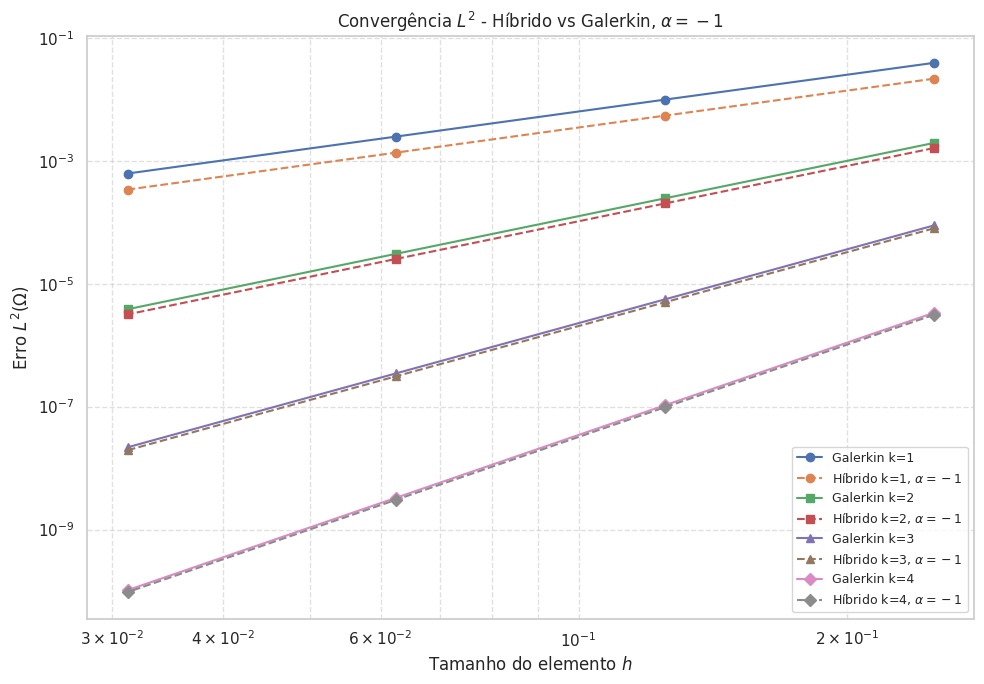

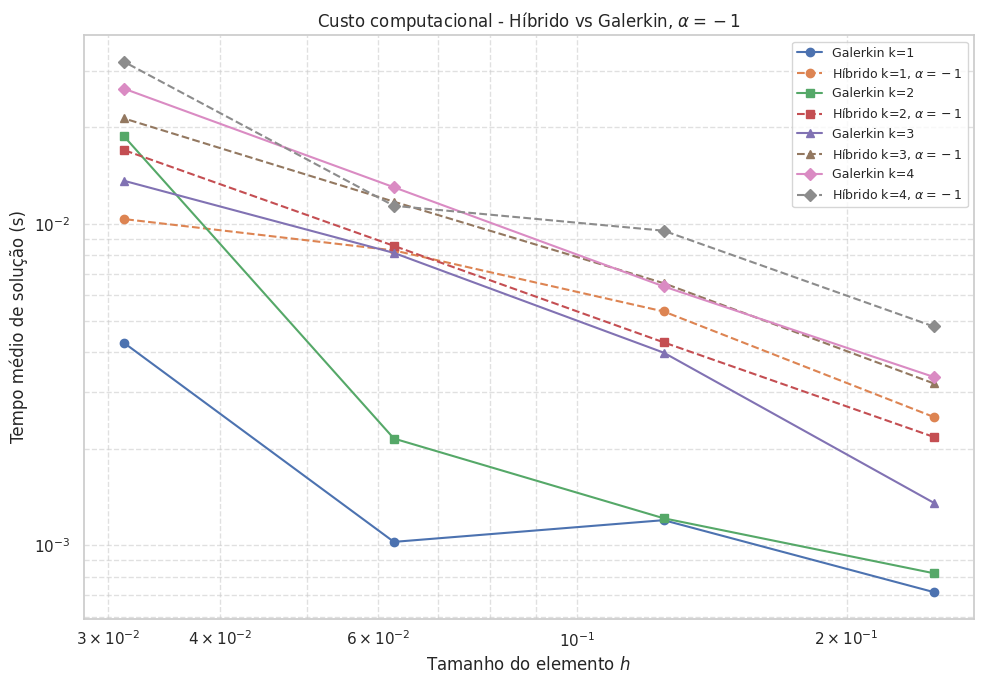


ESTUDO DE CONVERGÊNCIA - MÉTODO HÍBRIDO alpha = 0
-------------------------------------------------------------------------------------------------------------------
k   | Nelem  | h          | beta         | Erro L2        | Taxa     | Tempo médio (s) 
-------------------------------------------------------------------------------------------------------------------
1   | 4      | 0.2500     | 4.000e+01    | 2.678e-02      | 0.00     | 1.060885e-03    
1   | 8      | 0.1250     | 8.000e+01    | 6.774e-03      | 1.98     | 1.917032e-03    
1   | 16     | 0.0625     | 1.600e+02    | 1.698e-03      | 2.00     | 3.763757e-03    
1   | 32     | 0.0312     | 3.200e+02    | 4.249e-04      | 2.00     | 1.110095e-02    
-------------------------------------------------------------------------------------------------------------------
2   | 4      | 0.2500     | 1.600e+02    | 2.623e-03      | 0.00     | 2.213709e-03    
2   | 8      | 0.1250     | 3.200e+02    | 5.129e-04      | 2.35     | 4.

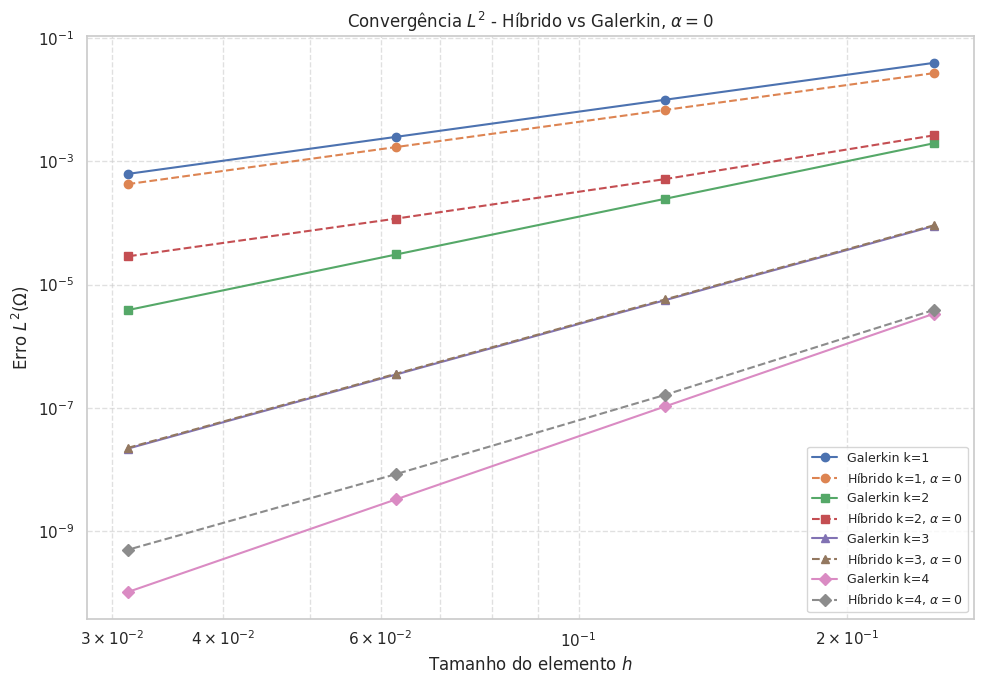

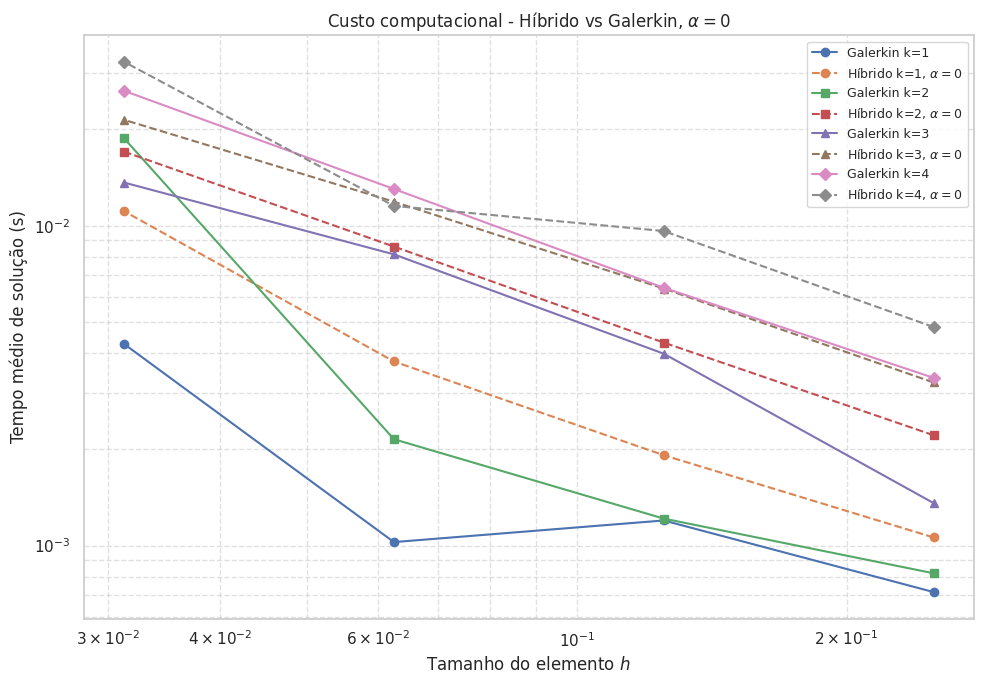


ESTUDO DE CONVERGÊNCIA - MÉTODO HÍBRIDO alpha = 1
-------------------------------------------------------------------------------------------------------------------
k   | Nelem  | h          | beta         | Erro L2        | Taxa     | Tempo médio (s) 
-------------------------------------------------------------------------------------------------------------------
1   | 4      | 0.2500     | 4.000e+01    | 3.061e-02      | 0.00     | 1.042865e-03    
1   | 8      | 0.1250     | 8.000e+01    | 7.767e-03      | 1.98     | 1.905915e-03    
1   | 16     | 0.0625     | 1.600e+02    | 1.949e-03      | 1.99     | 3.753840e-03    
1   | 32     | 0.0312     | 3.200e+02    | 4.877e-04      | 2.00     | 1.034875e-02    
-------------------------------------------------------------------------------------------------------------------
2   | 4      | 0.2500     | 1.600e+02    | 4.037e-03      | 0.00     | 2.173333e-03    
2   | 8      | 0.1250     | 3.200e+02    | 9.041e-04      | 2.16     | 4.

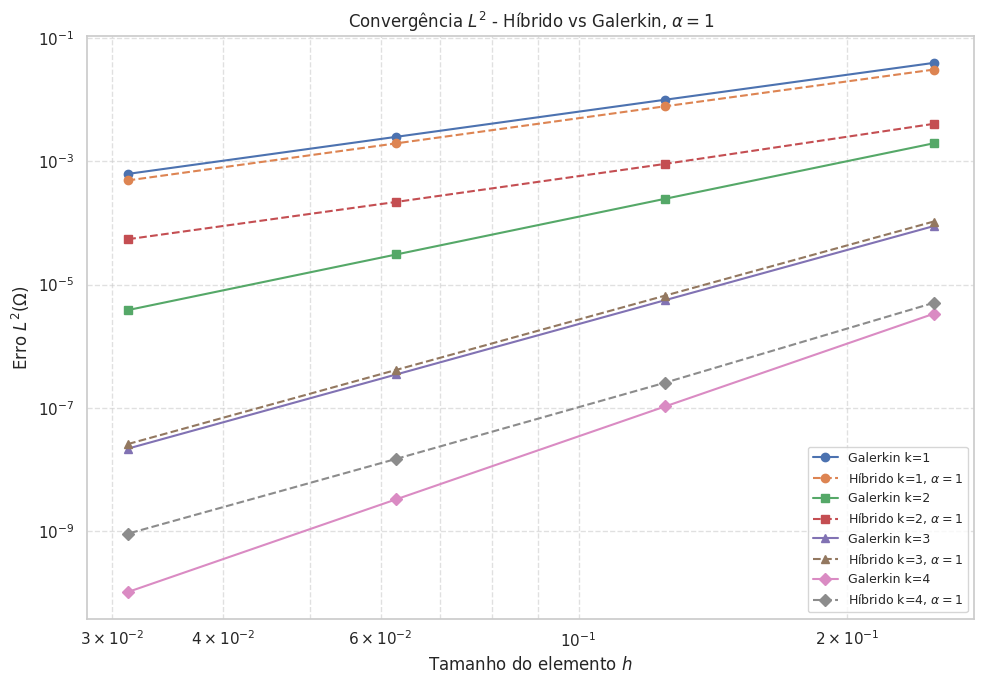

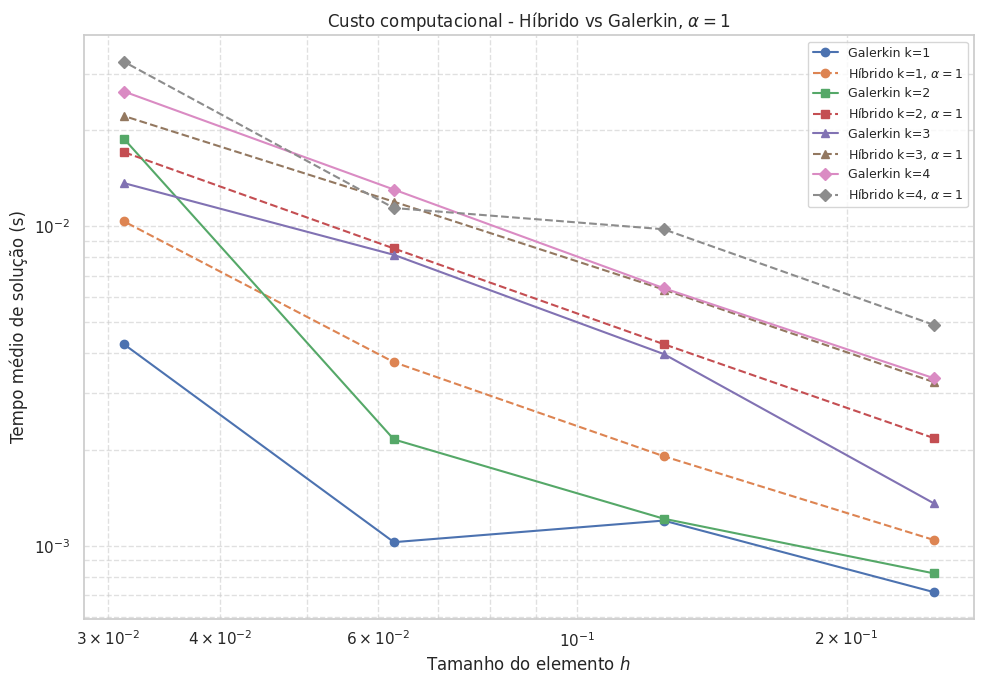

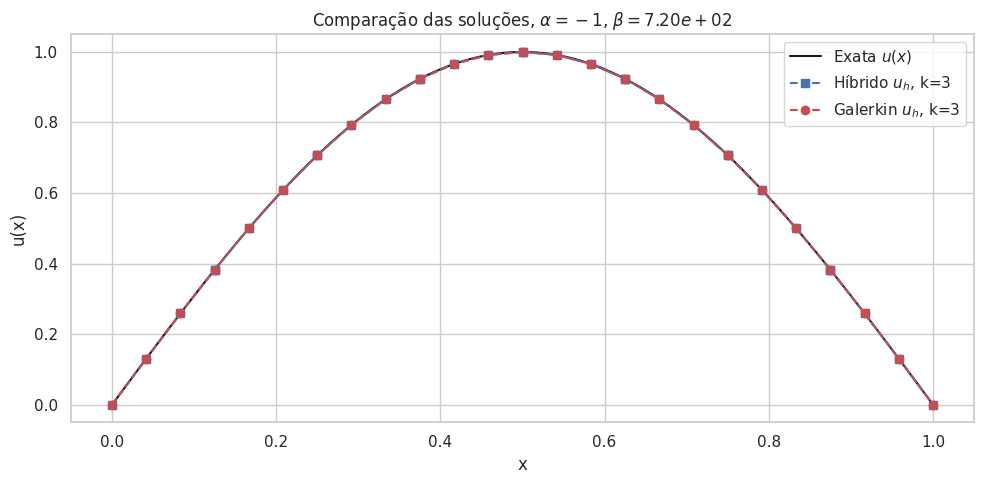

In [38]:
convergence_study_f()
plot_solution_example_f()